In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajifoster3/yolo-annotated-wind-turbines-586x371")

print("Path to dataset files:", path)


100%|██████████| 2.57G/2.57G [00:28<00:00, 97.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371/versions/1


In [ ]:
"""
MQ02 Wind Turbine Damage Detection - Colab + KaggleHub version

목적:
- 풍력 터빈 이미지에서 dirt / damage 객체를 탐지하는 모델을 학습합니다.
- KaggleHub로 받은 데이터셋을 YOLO 형식 train / val / test 폴더로 다시 나눕니다.
- 라벨이 없는 정상 이미지도 empty label 파일을 만들어 학습에 포함합니다.
- Early stopping, checkpoint 저장, best.pt 기반 test 평가까지 한 번에 수행합니다.

중요한 데이터 가정:
- 이미지와 이름이 같은 .txt 라벨 파일이 있으면 abnormal/labeled 샘플로 봅니다.
- 라벨 파일이 없는 이미지는 known-normal 샘플로 보고, 빈 YOLO 라벨 파일을 생성합니다.
- YOLO 계열 모델은 정상 이미지도 빈 .txt 파일이 있어야 안정적으로 학습됩니다.

실행 순서:
1) KaggleHub 다운로드 셀 실행
2) 이 학습 셀 실행
3) 학습 후 results.png 확인 셀 실행
4) 필요하면 결과 폴더 zip 다운로드 셀 실행
"""

import os
import sys
import random
import shutil
import subprocess
from pathlib import Path


# ============================================================
# 1. Settings
# ============================================================
# 이 구역은 실험 조건을 한곳에서 관리하는 설정판입니다.
# 모델, 학습 epoch, 이미지 크기, 데이터 분할 비율 등을 여기서 바꿉니다.

# 사용할 모델 파일명입니다.
# - "rtdetr-l.pt"는 Ultralytics의 RT-DETR large 모델입니다.
# - YOLO 모델을 쓰려면 예: "yolov8s.pt", "yolo11n.pt", "yolo11s.pt"처럼 바꾸면 됩니다.
MODEL = "rtdetr-l.pt"

# 데이터셋 경로를 직접 지정하고 싶을 때 사용합니다.
# None이면 아래 find_dataset_root() 함수가 KaggleHub / Colab 경로를 자동 탐색합니다.
# 직접 지정 예시: SRC = "/content/NordTank586x371/NordTank586x371"
SRC = None

# train / val / test로 재구성한 데이터셋을 저장할 폴더입니다.
# 실행할 때마다 기존 OUT 폴더는 삭제 후 새로 만들어집니다.
OUT = "./split"

# 학습 관련 기본 설정입니다.
EPOCHS = 25       # 최대 학습 epoch 수입니다. Early stopping 때문에 더 일찍 끝날 수 있습니다.
IMGSZ = 512       # 입력 이미지 크기입니다. 클수록 느리지만 작은 객체 탐지에 유리할 수 있습니다.
BATCH = -1        # -1은 Ultralytics가 GPU 메모리에 맞춰 batch size를 자동 선택한다는 뜻입니다.
SEED = 42         # 데이터 셔플과 분할 재현성을 위한 랜덤 시드입니다.
WORKERS = 2       # 데이터 로딩 worker 수입니다. Colab/Jupyter에서 너무 높이면 불안정할 수 있습니다.

# train / validation / test 분할 비율입니다.
# 현재는 80% 학습, 10% 검증, 10% 테스트입니다.
RATIO = (0.8, 0.1, 0.1)

# 라벨이 없는 이미지를 정상 이미지로 포함할지 여부입니다.
# 정상 이미지를 포함하면 모델이 "아무 객체도 없는 이미지"를 배울 수 있습니다.
INCLUDE_UNLABELED_NORMAL_IMAGES = True

# 정상 이미지가 너무 많으면 학습 데이터가 정상 쪽으로 과하게 치우칠 수 있으므로 최대 개수를 제한합니다.
# None으로 바꾸면 라벨 없는 정상 이미지를 전부 사용합니다.
NORMAL_IMAGE_LIMIT = 3000

# Early stopping과 checkpoint 관련 설정입니다.
EARLY_STOP_PATIENCE = 7  # 검증 성능이 7 epoch 동안 좋아지지 않으면 학습을 조기 종료합니다.
SAVE_PERIOD = -1         # -1이면 epoch별 checkpoint를 저장하지 않고 best.pt / last.pt 중심으로 저장합니다.
RESUME_TRAINING = True   # last.pt가 있으면 이어서 학습합니다.

# Ultralytics 학습 결과가 저장될 경로입니다.
# 최종 구조 예: runs/detect/rtdetr-l_balanced_fast/weights/best.pt
PROJECT_DIR = "runs"
RUN_NAME = Path(MODEL).stem + "_balanced_fast"

# KaggleHub에서 받을 데이터셋 식별자입니다.
DATASET_SLUG = "ajifoster3/yolo-annotated-wind-turbines-586x371"


# ============================================================
# 2. Package check / install
# ============================================================
# 이 구역은 필요한 패키지가 설치되어 있는지 확인하고, 없으면 설치합니다.


def pip_install(package_args):
    """현재 파이썬 환경에 필요한 패키지를 조용히(-q) 설치합니다."""
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + package_args
    print("Installing:", " ".join(package_args))
    subprocess.check_call(cmd)



def check_packages():
    """torch, ultralytics, kagglehub 사용 가능 여부를 확인합니다."""
    try:
        import torch
        print("torch OK:", torch.__version__)
    except Exception as exc:
        # torch가 없거나 GPU 런타임 설정이 꼬인 경우 학습 자체가 어렵습니다.
        raise RuntimeError(
            "torch import failed. In Colab, enable Runtime > Change runtime type > GPU, "
            "then restart runtime."
        ) from exc

    try:
        import ultralytics
        print("ultralytics OK:", ultralytics.__version__)
    except Exception:
        # YOLO / RT-DETR 학습을 위해 ultralytics가 필요합니다.
        pip_install(["ultralytics"])
        import ultralytics
        print("ultralytics installed:", ultralytics.__version__)

    try:
        import kagglehub
        print("kagglehub OK")
    except Exception:
        # Kaggle 데이터셋 다운로드를 위해 kagglehub가 필요합니다.
        pip_install(["kagglehub"])
        import kagglehub
        print("kagglehub installed")


def get_device():
    import torch

    if torch.cuda.is_available():
        print("CUDA available. Using GPU 0.")
        return 0

    print("CUDA not available. Using CPU.")
    return "cpu"


# ============================================================
# 3. Dataset root search
# ============================================================
# KaggleHub 데이터셋은 환경마다 폴더 깊이가 다르게 잡힐 수 있습니다.
# 그래서 images/ 와 labels/ 가 함께 있는 실제 루트 폴더를 자동으로 찾습니다.

def get_image_files(img_dir):
    """이미지 폴더에서 지원 확장자의 이미지 파일을 중복 없이 수집합니다."""
    img_dir = Path(img_dir)
    exts = [".png", ".jpg", ".jpeg", ".bmp", ".webp"]

    images = []

    # 소문자 / 대문자 확장자를 모두 확인합니다.
    for ext in exts:
        images.extend(img_dir.glob(f"*{ext}"))
        images.extend(img_dir.glob(f"*{ext.upper()}"))

    # 같은 파일이 중복으로 들어오는 것을 방지하기 위해 resolve 경로 기준으로 unique 처리합니다.
    unique = {}
    for image_path in images:
        unique[str(image_path.resolve())] = image_path

    # stem 기준 정렬로 실행마다 순서를 안정적으로 유지합니다.
    return sorted(unique.values(), key=lambda p: p.stem)


def count_labeled_pairs(root):
    """root/images와 root/labels에서 이미지-라벨 이름이 매칭되는 개수를 셉니다."""
    root = Path(root)
    img_dir = root / "images"
    lbl_dir = root / "labels"

    if not img_dir.exists() or not lbl_dir.exists():
        return 0

    image_stems = set(p.stem for p in get_image_files(img_dir))
    label_stems = set(
        p.stem for p in lbl_dir.glob("*.txt")
        if p.name.lower() != "labels.txt"
    )

    # 이미지 이름과 라벨 이름이 같은 경우만 실제 학습 가능한 labeled pair입니다.
    return len(image_stems & label_stems)



def count_total_images(root):
    """root/images 안에 있는 전체 이미지 수를 셉니다."""
    root = Path(root)
    img_dir = root / "images"

    if not img_dir.exists():
        return 0

    return len(get_image_files(img_dir))


def candidate_roots_from_base(base_path):
    """가능한 데이터셋 루트 후보들을 생성합니다."""
    base = Path(base_path).expanduser().resolve()

    # Kaggle 데이터셋은 NordTank586x371 폴더가 한 번 또는 두 번 중첩되어 있을 수 있습니다.
    candidates = [
        base,
        base / "NordTank586x371",
        base / "NordTank586x371" / "NordTank586x371",
    ]

    if base.exists():
        try:
            # 하위 폴더를 훑으며 images/와 labels/가 함께 있는 폴더를 추가 후보로 넣습니다.
            for p in base.rglob("*"):
                if not p.is_dir():
                    continue

                if (p / "images").exists() and (p / "labels").exists():
                    candidates.append(p)

                if p.name == "NordTank586x371":
                    candidates.append(p)
                    candidates.append(p / "NordTank586x371")
        except Exception as exc:
            # 권한 문제 등으로 탐색 실패해도 전체 실행이 멈추지 않도록 합니다.
            print("Nested search skipped for:", base, repr(exc))

    unique = []
    seen = set()

    # 같은 경로가 여러 번 들어갈 수 있으므로 중복 제거합니다.
    for c in candidates:
        try:
            c = Path(c).expanduser().resolve()
        except Exception:
            continue

        key = str(c)
        if key not in seen:
            seen.add(key)
            unique.append(c)

    return unique


def get_colab_kagglehub_path_from_globals():
    """앞 셀에서 만든 path 변수 또는 환경변수에서 KaggleHub 경로를 가져옵니다."""
    value = globals().get("path", None)

    if value is not None:
        print("Found global variable path:", value)
        return value

    value = os.environ.get("KAGGLEHUB_DATASET_PATH", None)

    if value:
        print("Found env KAGGLEHUB_DATASET_PATH:", value)
        return value

    return None

def download_with_kagglehub_if_needed():
    """자동 탐색에 실패했을 때 KaggleHub로 데이터셋을 다시 찾거나 다운로드합니다."""
    import kagglehub

    print("Downloading or locating KaggleHub dataset:", DATASET_SLUG)
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
    print("KaggleHub dataset path:", dataset_path)
    return dataset_path


def select_best_dataset_root(bases):
    """후보 경로들 중 labeled pair가 가장 많고, 그다음 전체 이미지가 많은 경로를 선택합니다."""
    checked = []
    best_path = None
    best_labeled = 0
    best_total = 0

    for base in bases:
        for candidate in candidate_roots_from_base(base):
            labeled_count = count_labeled_pairs(candidate)
            total_images = count_total_images(candidate)

            checked.append((candidate, labeled_count, total_images))

            # 1순위: 이미지-라벨 매칭 수
            # 2순위: 전체 이미지 수
            if (labeled_count > best_labeled) or (
                labeled_count == best_labeled and total_images > best_total
            ):
                best_path = candidate
                best_labeled = labeled_count
                best_total = total_images

    return best_path, best_labeled, best_total, checked


def find_dataset_root():
    """학습에 사용할 실제 데이터셋 루트 폴더를 최종 결정합니다."""
    if SRC is not None:
        # 사용자가 직접 경로를 지정한 경우, 그 경로와 하위 후보만 검사합니다.
        src_path = Path(SRC).expanduser().resolve()

        best_path, best_labeled, best_total, checked = select_best_dataset_root([src_path])

        print("Manual SRC:", src_path)
        print("Best nested root:", best_path)
        print("Labeled pairs:", best_labeled)
        print("Total images:", best_total)

        if best_labeled > 0 and best_total > 0:
            return best_path

        raise FileNotFoundError(
            "Manual SRC is invalid.\n"
            f"SRC: {src_path}\n"
            "SRC must be the folder or parent folder containing images/ and labels/."
        )

    bases = []

    # 앞 KaggleHub 다운로드 셀에서 생성한 path가 있으면 가장 먼저 검사합니다.
    global_path = get_colab_kagglehub_path_from_globals()
    if global_path is not None:
        bases.append(global_path)

    # Colab / KaggleHub에서 자주 나오는 후보 경로들입니다.
    bases.extend([
        "/content/NordTank586x371",
        "/content/NordTank586x371/NordTank586x371",
        "/root/.cache/kagglehub/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371/versions/1",
        "/root/.cache/kagglehub/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371/versions/1/NordTank586x371",
        "/root/.cache/kagglehub/datasets/ajifoster3/yolo-annotated-wind-turbines-586x371/versions/1/NordTank586x371/NordTank586x371",
        "./NordTank586x371",
        "./NordTank586x371/NordTank586x371",
    ])

    best_path, best_labeled, best_total, checked = select_best_dataset_root(bases)

    if best_labeled > 0 and best_total > 0:
        print("Auto-selected dataset root:", best_path)
        print("Labeled pairs:", best_labeled)
        print("Total images:", best_total)
        return best_path

    # 후보 경로 탐색에 실패하면 KaggleHub 다운로드/캐시 경로를 다시 시도합니다.
    try:
        downloaded_path = download_with_kagglehub_if_needed()

        best_path, best_labeled, best_total, checked2 = select_best_dataset_root([downloaded_path])
        checked.extend(checked2)

        if best_labeled > 0 and best_total > 0:
            print("Auto-selected dataset root:", best_path)
            print("Labeled pairs:", best_labeled)
            print("Total images:", best_total)
            return best_path

    except Exception as exc:
        print("KaggleHub fallback failed:", repr(exc))

    print("")
    print("Auto-search failed.")
    print("Checked paths:")
    for p, labeled, total in checked:
        print(" ", p, "labeled:", labeled, "total_images:", total)

    raise FileNotFoundError(
        "Could not find dataset folder. Set SRC manually to the folder or parent folder "
        "that contains images/ and labels/."
    )


# ============================================================
# 4. Dataset utilities
# ============================================================
# 데이터 분할과 복사에 필요한 작은 보조 함수들입니다.

def find_image_by_base(img_dir, base):
    """base 이름에 해당하는 이미지 파일을 여러 확장자 후보 중에서 찾습니다."""
    img_dir = Path(img_dir)
    exts = [".png", ".jpg", ".jpeg", ".bmp", ".webp"]

    for ext in exts:
        p = img_dir / f"{base}{ext}"
        if p.exists():
            return p

        p_upper = img_dir / f"{base}{ext.upper()}"
        if p_upper.exists():
            return p_upper

    return None


def label_has_dirt(label_path):
    """라벨 파일 안에 class 0(dirt)이 하나라도 있는지 확인합니다."""
    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            # YOLO 라벨 한 줄 구조: class_id x_center y_center width height
            # class_id가 0이면 dirt로 간주합니다.
            if line.strip().startswith("0 "):
                return True

    return False


def split_group(group):
    """한 그룹을 train / val / test 비율에 맞게 나눕니다."""
    # 먼저 정렬한 뒤 고정 시드로 섞으면 매 실행마다 같은 분할이 만들어집니다.
    group = sorted(group, key=lambda x: x["base"])
    random.Random(SEED).shuffle(group)

    n = len(group)
    train_end = int(n * RATIO[0])
    val_end = train_end + int(n * RATIO[1])

    return group[:train_end], group[train_end:val_end], group[val_end:]


def copy_yolo_item(item, image_out_dir, label_out_dir):
    """이미지와 라벨을 YOLO 폴더 구조에 맞게 복사합니다."""
    image_path = item["image_path"]
    label_path = item["label_path"]
    base = item["base"]

    # 이미지 파일은 원본 메타데이터를 최대한 보존하며 복사합니다.
    shutil.copy2(image_path, image_out_dir / image_path.name)

    output_label_path = label_out_dir / f"{base}.txt"

    if label_path is None:
        # Known-normal sample 처리입니다.
        # YOLO는 이미지마다 대응되는 .txt가 있는 편이 안정적이므로 빈 라벨 파일을 생성합니다.
        output_label_path.write_text("", encoding="utf-8")
    else:
        # 라벨이 있는 abnormal 샘플은 원본 라벨 파일을 그대로 복사합니다.
        shutil.copy2(label_path, output_label_path)


# ============================================================
# 5. Split preparation
# ============================================================
# 원본 데이터셋을 읽어서 ./split/train, ./split/val, ./split/test 구조로 변환합니다.

def prepare_split():
    """데이터셋을 탐색하고 YOLO 학습용 train/val/test split을 생성합니다."""
    src_path = find_dataset_root()

    img_dir = src_path / "images"
    lbl_dir = src_path / "labels"

    print("Final SRC:", src_path)
    print("Image folder:", img_dir)
    print("Label folder:", lbl_dir)

    all_images = get_image_files(img_dir)

    # labels.txt는 클래스 설명 파일일 수 있으므로 실제 객체 라벨에서 제외합니다.
    label_files = sorted(
        p for p in lbl_dir.glob("*.txt")
        if p.name.lower() != "labels.txt"
    )

    # 이미지 stem으로 대응 라벨을 빠르게 찾기 위한 딕셔너리입니다.
    label_by_stem = {p.stem: p for p in label_files}

    print("Total image files:", len(all_images))
    print("Label txt files:", len(label_files))

    abnormal_items = []
    normal_items = []

    for image_path in all_images:
        base = image_path.stem
        label_path = label_by_stem.get(base)

        if label_path is not None:
            # 라벨 파일이 있으면 객체가 표시된 abnormal/labeled 이미지로 분류합니다.
            abnormal_items.append(
                {
                    "base": base,
                    "image_path": image_path,
                    "label_path": label_path,
                    "kind": "abnormal_labeled",
                    "has_dirt": label_has_dirt(label_path),
                }
            )
        else:
            # 라벨 파일이 없는 이미지는 정상 이미지로 볼 수 있습니다.
            # INCLUDE_UNLABELED_NORMAL_IMAGES가 True일 때만 학습에 포함합니다.
            if INCLUDE_UNLABELED_NORMAL_IMAGES:
                normal_items.append(
                    {
                        "base": base,
                        "image_path": image_path,
                        "label_path": None,
                        "kind": "normal_empty_label",
                        "has_dirt": False,
                    }
                )

    if NORMAL_IMAGE_LIMIT is not None:
        # 정상 이미지가 너무 많을 경우 class imbalance를 완화하기 위해 일부만 사용합니다.
        normal_items = sorted(normal_items, key=lambda x: x["base"])
        random.Random(SEED).shuffle(normal_items)
        normal_items = normal_items[:NORMAL_IMAGE_LIMIT]

    image_stems = set(p.stem for p in all_images)
    label_stems = set(label_by_stem.keys())
    labels_without_images = sorted(label_stems - image_stems)

    print("Abnormal labeled images:", len(abnormal_items))
    print("Known-normal unlabeled images:", len(normal_items))
    print("Labels without matching image:", len(labels_without_images))
    print("Normal image limit:", NORMAL_IMAGE_LIMIT)

    if len(abnormal_items) == 0:
        raise RuntimeError(
            "No labeled abnormal images found. "
            "Check that image and label names match."
        )

    # dirt가 있는 abnormal, dirt가 없는 abnormal, 정상 이미지를 따로 나눕니다.
    # 이렇게 하면 특정 그룹이 train/val/test 중 한쪽으로 몰리는 것을 줄일 수 있습니다.
    dirt_items = [it for it in abnormal_items if it["has_dirt"]]
    no_dirt_abnormal_items = [it for it in abnormal_items if not it["has_dirt"]]

    dirt_split = split_group(dirt_items)
    no_dirt_abnormal_split = split_group(no_dirt_abnormal_items)
    normal_split = split_group(normal_items)

    # 각 그룹별 분할 결과를 합쳐 최종 train/val/test를 만듭니다.
    splits = {
        "train": dirt_split[0] + no_dirt_abnormal_split[0] + normal_split[0],
        "val": dirt_split[1] + no_dirt_abnormal_split[1] + normal_split[1],
        "test": dirt_split[2] + no_dirt_abnormal_split[2] + normal_split[2],
    }

    out_path = Path(OUT).resolve()

    # 이전에 만든 split 폴더가 있으면 삭제합니다.
    # 주의: OUT 경로를 중요 폴더로 지정하면 안 됩니다.
    if out_path.exists():
        shutil.rmtree(out_path)

    # YOLO 표준 폴더 구조를 생성합니다.
    # split/train/images, split/train/labels 같은 구조입니다.
    for split_name, rows in splits.items():
        image_out_dir = out_path / split_name / "images"
        label_out_dir = out_path / split_name / "labels"

        image_out_dir.mkdir(parents=True, exist_ok=True)
        label_out_dir.mkdir(parents=True, exist_ok=True)

        for item in rows:
            copy_yolo_item(item, image_out_dir, label_out_dir)

    # 분할 결과가 의도대로 만들어졌는지 요약 출력합니다.
    for split_name in ["train", "val", "test"]:
        rows = splits[split_name]

        abnormal_count = sum(1 for row in rows if row["kind"] == "abnormal_labeled")
        normal_count = sum(1 for row in rows if row["kind"] == "normal_empty_label")
        dirt_count = sum(1 for row in rows if row["has_dirt"])

        image_count = len(list((out_path / split_name / "images").glob("*")))
        label_count = len(list((out_path / split_name / "labels").glob("*.txt")))

        empty_label_count = 0
        for label_path in (out_path / split_name / "labels").glob("*.txt"):
            text = label_path.read_text(encoding="utf-8", errors="ignore").strip()
            if text == "":
                empty_label_count += 1

        print(
            f"{split_name:5} total: {len(rows):5} | "
            f"abnormal: {abnormal_count:5} | "
            f"normal: {normal_count:5} | "
            f"dirt: {dirt_count:5} | "
            f"images: {image_count:5} | "
            f"labels: {label_count:5} | "
            f"empty labels: {empty_label_count:5}"
        )

    # 학습과 검증 데이터가 없으면 모델 학습이 불가능하므로 즉시 에러를 냅니다.
    if len(splits["train"]) == 0:
        raise RuntimeError("Train split is empty. Cannot train YOLO.")

    if len(splits["val"]) == 0:
        raise RuntimeError("Val split is empty. Cannot train YOLO safely.")

    # Ultralytics가 읽을 data.yaml 파일을 생성합니다.
    # nc는 클래스 수, names는 클래스 id와 이름 매핑입니다.
    data_yaml_path = out_path / "data.yaml"

    yaml_text = f"""path: {out_path}
train: train/images
val: val/images
test: test/images

nc: 2
names:
  0: dirt
  1: damage
"""

    data_yaml_path.write_text(yaml_text, encoding="utf-8")

    print("data.yaml:", data_yaml_path)

    return str(data_yaml_path), len(splits["test"])


# ============================================================
# 6. Early stop and checkpoint helpers
# ============================================================
# 학습 중 저장되는 best.pt / last.pt 위치를 일관되게 관리합니다.

def get_run_dir():
    """Ultralytics가 이번 실험 결과를 저장하는 run 폴더를 반환합니다."""
    return Path(PROJECT_DIR) / "detect" / RUN_NAME


def get_weights_dir():
    """checkpoint 파일들이 저장되는 weights 폴더를 반환합니다."""
    return get_run_dir() / "weights"


def get_last_checkpoint_path():
    """가장 마지막 epoch 상태가 저장된 last.pt 경로입니다."""
    return get_weights_dir() / "last.pt"


def get_best_checkpoint_path():
    """검증 성능 기준으로 가장 좋았던 best.pt 경로입니다."""
    return get_weights_dir() / "best.pt"


def find_resume_checkpoint():
    """이어 학습할 last.pt가 있는지 확인합니다."""
    last_ckpt = get_last_checkpoint_path()

    if RESUME_TRAINING and last_ckpt.exists():
        print("Resume checkpoint found:", last_ckpt)
        return last_ckpt

    print("No resume checkpoint found. Training will start from base model.")
    return None


def print_checkpoint_summary():
    """학습 후 저장된 checkpoint 파일들을 출력합니다."""
    weights_dir = get_weights_dir()

    print("")
    print("Checkpoint summary")
    print("==================")

    if not weights_dir.exists():
        print("Weights folder not found:", weights_dir)
        return

    best_ckpt = get_best_checkpoint_path()
    last_ckpt = get_last_checkpoint_path()

    if best_ckpt.exists():
        print("Best checkpoint:", best_ckpt)
    else:
        print("Best checkpoint: not found")

    if last_ckpt.exists():
        print("Last checkpoint:", last_ckpt)
    else:
        print("Last checkpoint: not found")

    epoch_checkpoints = sorted(weights_dir.glob("epoch*.pt"))

    if epoch_checkpoints:
        print("Periodic checkpoints:")
        for ckpt in epoch_checkpoints:
            print(" -", ckpt)
    else:
        print("Periodic checkpoints: none")


# ============================================================
# 7. Train and evaluate
# ============================================================
# 모델 객체를 만들고, 학습하고, best checkpoint로 test set 평가까지 수행합니다.

def train_and_evaluate(data_yaml, test_count):
    """Ultralytics 모델을 학습하고 test split으로 최종 성능을 평가합니다."""
    model_name = MODEL.strip()

    # 흔한 오타 방지용입니다. Ultralytics 모델명은 yolov11n.pt가 아니라 yolo11n.pt 계열입니다.
    if model_name == "yolov11n.pt":
        raise ValueError("Wrong model name: use yolo11s.pt, not yolov11n.pt.")

    from ultralytics import YOLO, RTDETR

    # RT-DETR 모델과 YOLO 모델은 생성 클래스가 다릅니다.
    if model_name.lower().startswith("rtdetr"):
        Net = RTDETR
    else:
        Net = YOLO

    device = get_device()

    resume_ckpt = find_resume_checkpoint()

    if resume_ckpt is not None:
        # last.pt가 있으면 이전 학습을 이어서 진행합니다.
        print("Training mode: resume")
        print("Loading checkpoint:", resume_ckpt)
        model = Net(str(resume_ckpt))
        resume_flag = True
    else:
        # checkpoint가 없으면 base pretrained model에서 새로 시작합니다.
        print("Training mode: new")
        print("Base model:", model_name)
        model = Net(model_name)
        resume_flag = False

    print("Training model:", model_name)
    print("Early stop patience:", EARLY_STOP_PATIENCE)
    print("Save period:", SAVE_PERIOD)
    print("Run directory:", get_run_dir())

    # Ultralytics train()에 전달할 주요 학습 옵션입니다.
    train_kwargs = dict(
        data=data_yaml,                 # prepare_split()에서 만든 data.yaml 경로
        epochs=EPOCHS,                  # 최대 epoch
        imgsz=IMGSZ,                    # 입력 이미지 크기
        batch=BATCH,                    # -1이면 자동 batch
        device=device,                  # GPU 0 또는 CPU
        seed=SEED,                      # 재현성용 seed
        project=PROJECT_DIR,            # runs 상위 폴더
        name=RUN_NAME,                  # 이번 실험 이름
        exist_ok=True,                  # 같은 이름 폴더가 있어도 이어서 사용 가능
        workers=WORKERS,                # dataloader worker 수
        cache="disk",                  # 이미지를 disk cache하여 반복 로딩 속도를 높임
        amp=True,                       # mixed precision 사용, GPU 메모리 절약/속도 향상
        optimizer="auto",              # Ultralytics가 모델에 맞는 optimizer 자동 선택
        patience=EARLY_STOP_PATIENCE,   # early stopping patience
        save=True,                      # best.pt / last.pt 저장
        save_period=SAVE_PERIOD,        # epoch별 checkpoint 저장 주기
        plots=True,                     # results.png 등 학습 그래프 저장
        freeze=10,                      # 앞쪽 10개 layer를 freeze하여 빠르고 안정적으로 미세조정
    )

    if resume_flag:
        # resume=True는 optimizer 상태와 epoch 진행 상태까지 이어서 사용하게 합니다.
        train_kwargs["resume"] = True

    model.train(**train_kwargs)

    print_checkpoint_summary()

    if test_count > 0:
        best_ckpt = get_best_checkpoint_path()

        if best_ckpt.exists():
            # 최종 평가는 현재 마지막 모델이 아니라 검증 성능이 가장 좋았던 best.pt로 수행합니다.
            print("")
            print("Loading best checkpoint for final test evaluation:", best_ckpt)
            eval_model = Net(str(best_ckpt))
        else:
            print("")
            print("Best checkpoint not found. Evaluating current model object.")
            eval_model = model

        print("Test evaluation started.")

        # 자동 batch(-1)는 val에서 문제가 생길 수 있어 평가 시에는 16으로 고정합니다.
        eval_batch = 16 if BATCH == -1 else BATCH

        metrics = eval_model.val(
            data=data_yaml,
            split="test",
            device=device,
            imgsz=IMGSZ,
            batch=eval_batch,
            workers=WORKERS,
        )

        # mAP50은 IoU 0.5 기준 평균 정밀도입니다.
        # mAP50-95는 IoU 0.5~0.95 범위에서 평균낸 더 엄격한 지표입니다.
        print("test mAP50:", round(float(metrics.box.map50), 4))
        print("test mAP50-95:", round(float(metrics.box.map), 4))
    else:
        print("Test evaluation skipped because test split is empty.")

# ============================================================
# 8. Main
# ============================================================
# 전체 파이프라인의 진입점입니다.

def main():
    # 1) 패키지와 GPU/CPU 환경을 확인합니다.
    check_packages()

    # 2) 데이터셋을 YOLO 학습 구조로 재구성합니다.
    print("[1/2] Preparing split.")
    data_yaml, test_count = prepare_split()

    # 3) 모델을 학습하고 test set으로 평가합니다.
    print("[2/2] Training.")
    train_and_evaluate(data_yaml, test_count)

    print("Finished.")


# 노트북에서 셀을 직접 실행하면 __name__ == "__main__" 조건이 참이므로 main()이 실행됩니다.
# 만약 이 파일을 다른 파이썬 파일에서 import하면 main()은 자동 실행되지 않습니다.
if __name__ == "__main__":
    main()



torch OK: 2.11.0+cu128
ultralytics OK: 8.4.83
kagglehub OK
[1/2] Preparing split.
Using Colab cache for faster access to the 'yolo-annotated-wind-turbines-586x371' dataset.
KaggleHub dataset path: /kaggle/input/yolo-annotated-wind-turbines-586x371
Auto-selected dataset root: /kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371
Labeled pairs: 2995
Total images: 13470
Final SRC: /kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371
Image folder: /kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371/images
Label folder: /kaggle/input/yolo-annotated-wind-turbines-586x371/NordTank586x371/labels
Total image files: 13470
Label txt files: 2995
Abnormal labeled images: 2995
Known-normal unlabeled images: 3000
Labels without matching image: 0
Normal image limit: 3000
train total:  4795 | abnormal:  2395 | normal:  2400 | dirt:   450 | images:  4795 | labels:  4795 | empty labels:  2400
val   total:   599 | abnormal:   299 | normal:   300 | dirt:    56 | im

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/25      2.82G      1.519      15.46     0.5086         19       1024: 2% ──────────── 62/2398 2.1it/s 26.8s<18:56

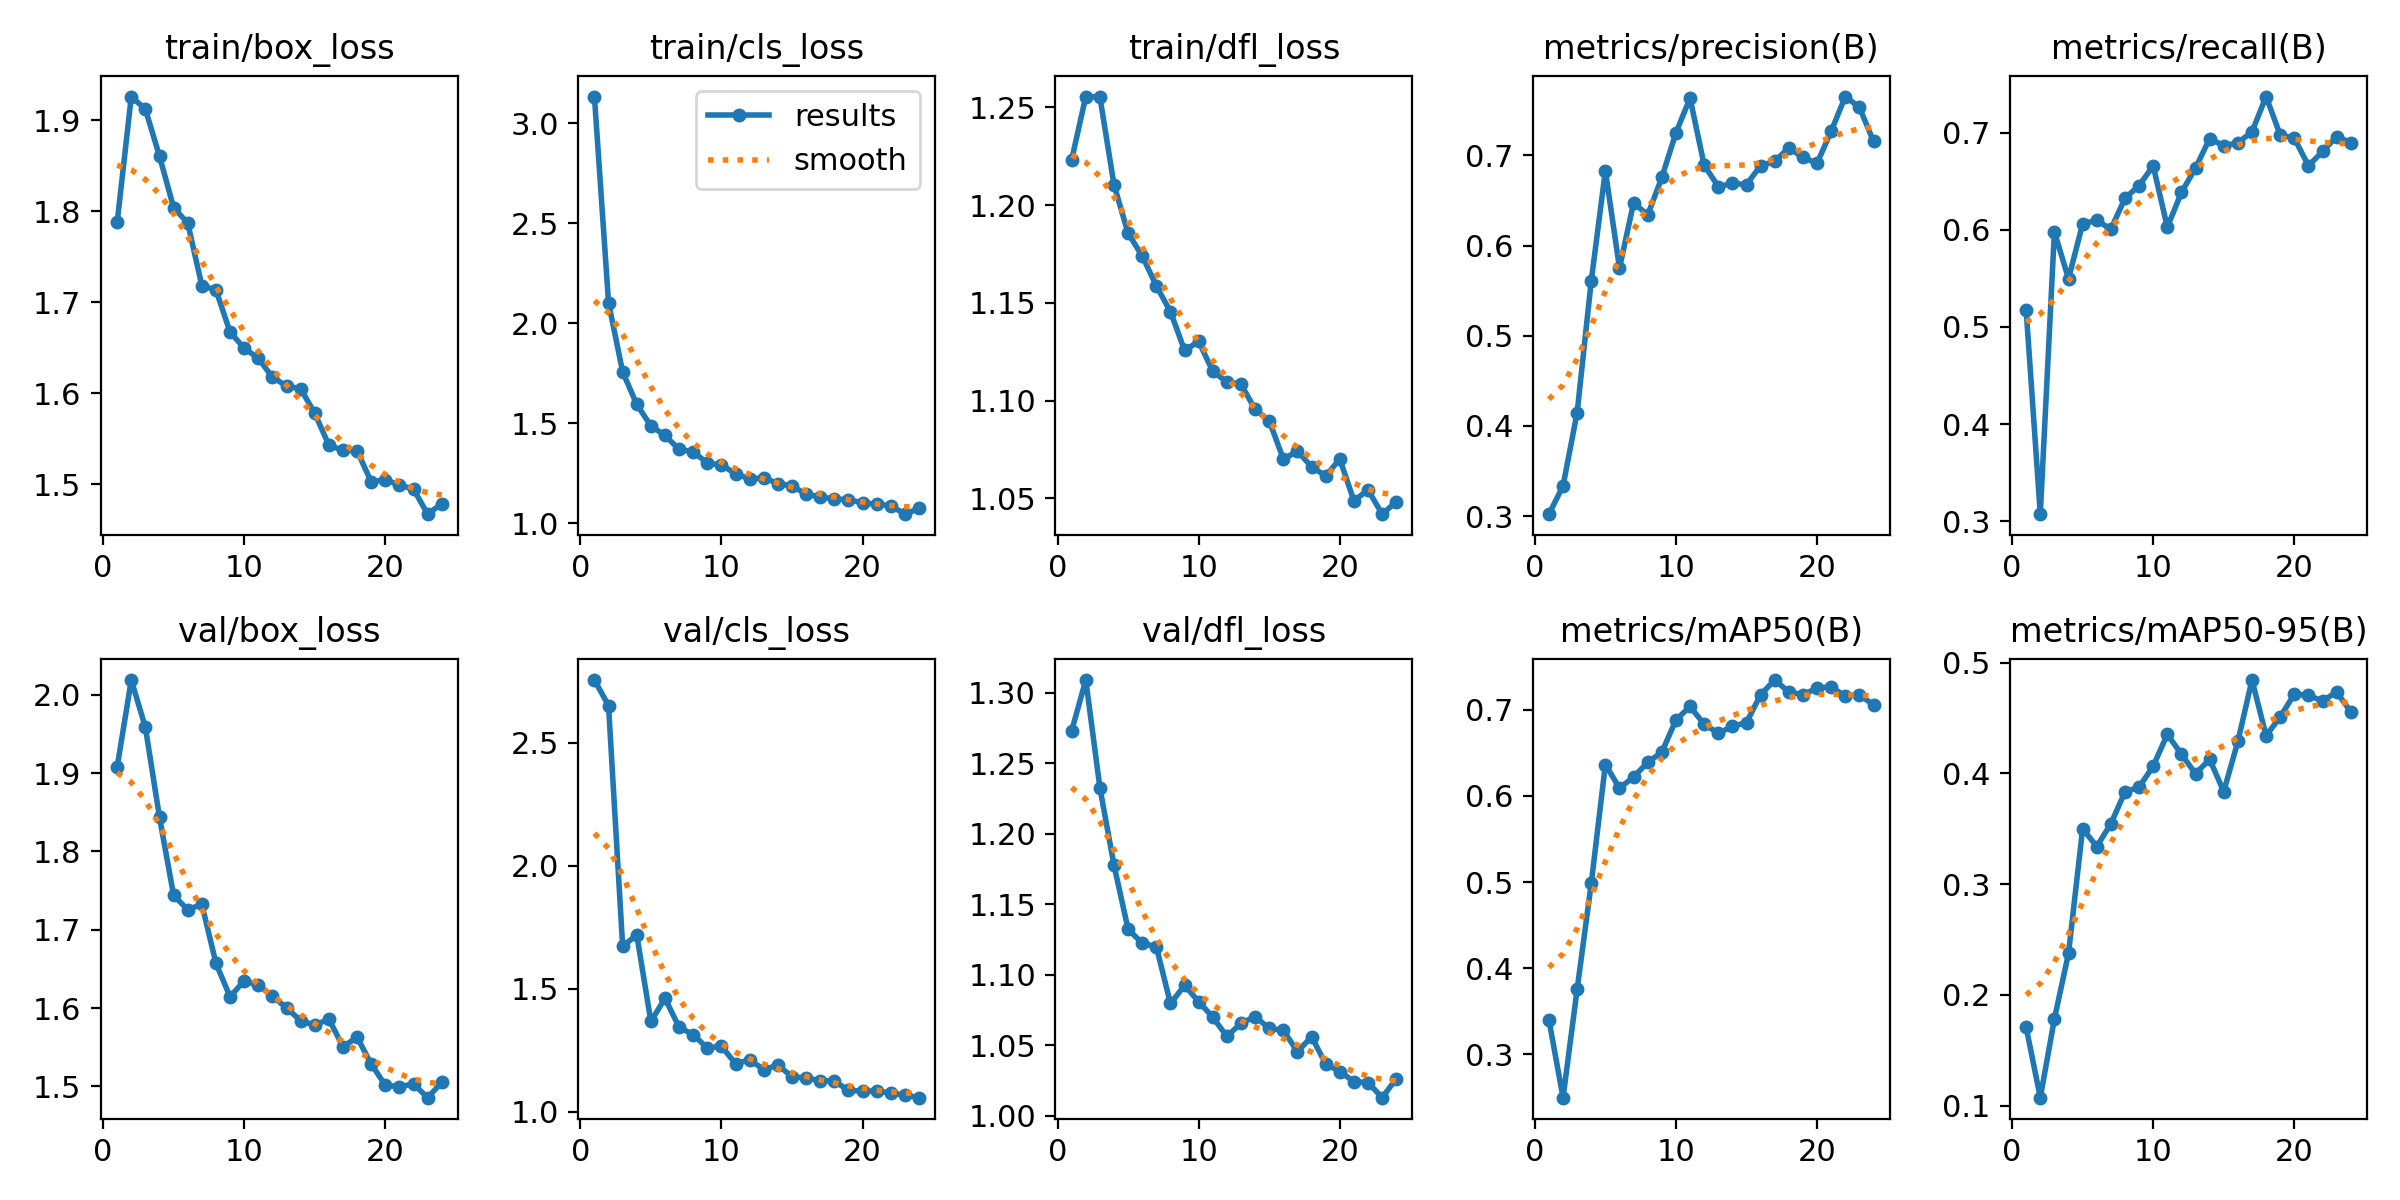

In [ ]:
from pathlib import Path
from IPython.display import Image, display

result_png = Path("/content/runs/detect/runs/yolo11n_balanced_fast/results.png")

if result_png.exists():
    display(Image(filename=str(result_png)))
else:
    print("results.png not found yet. It may appear after training progresses.")
    print("Checked path:", result_png)

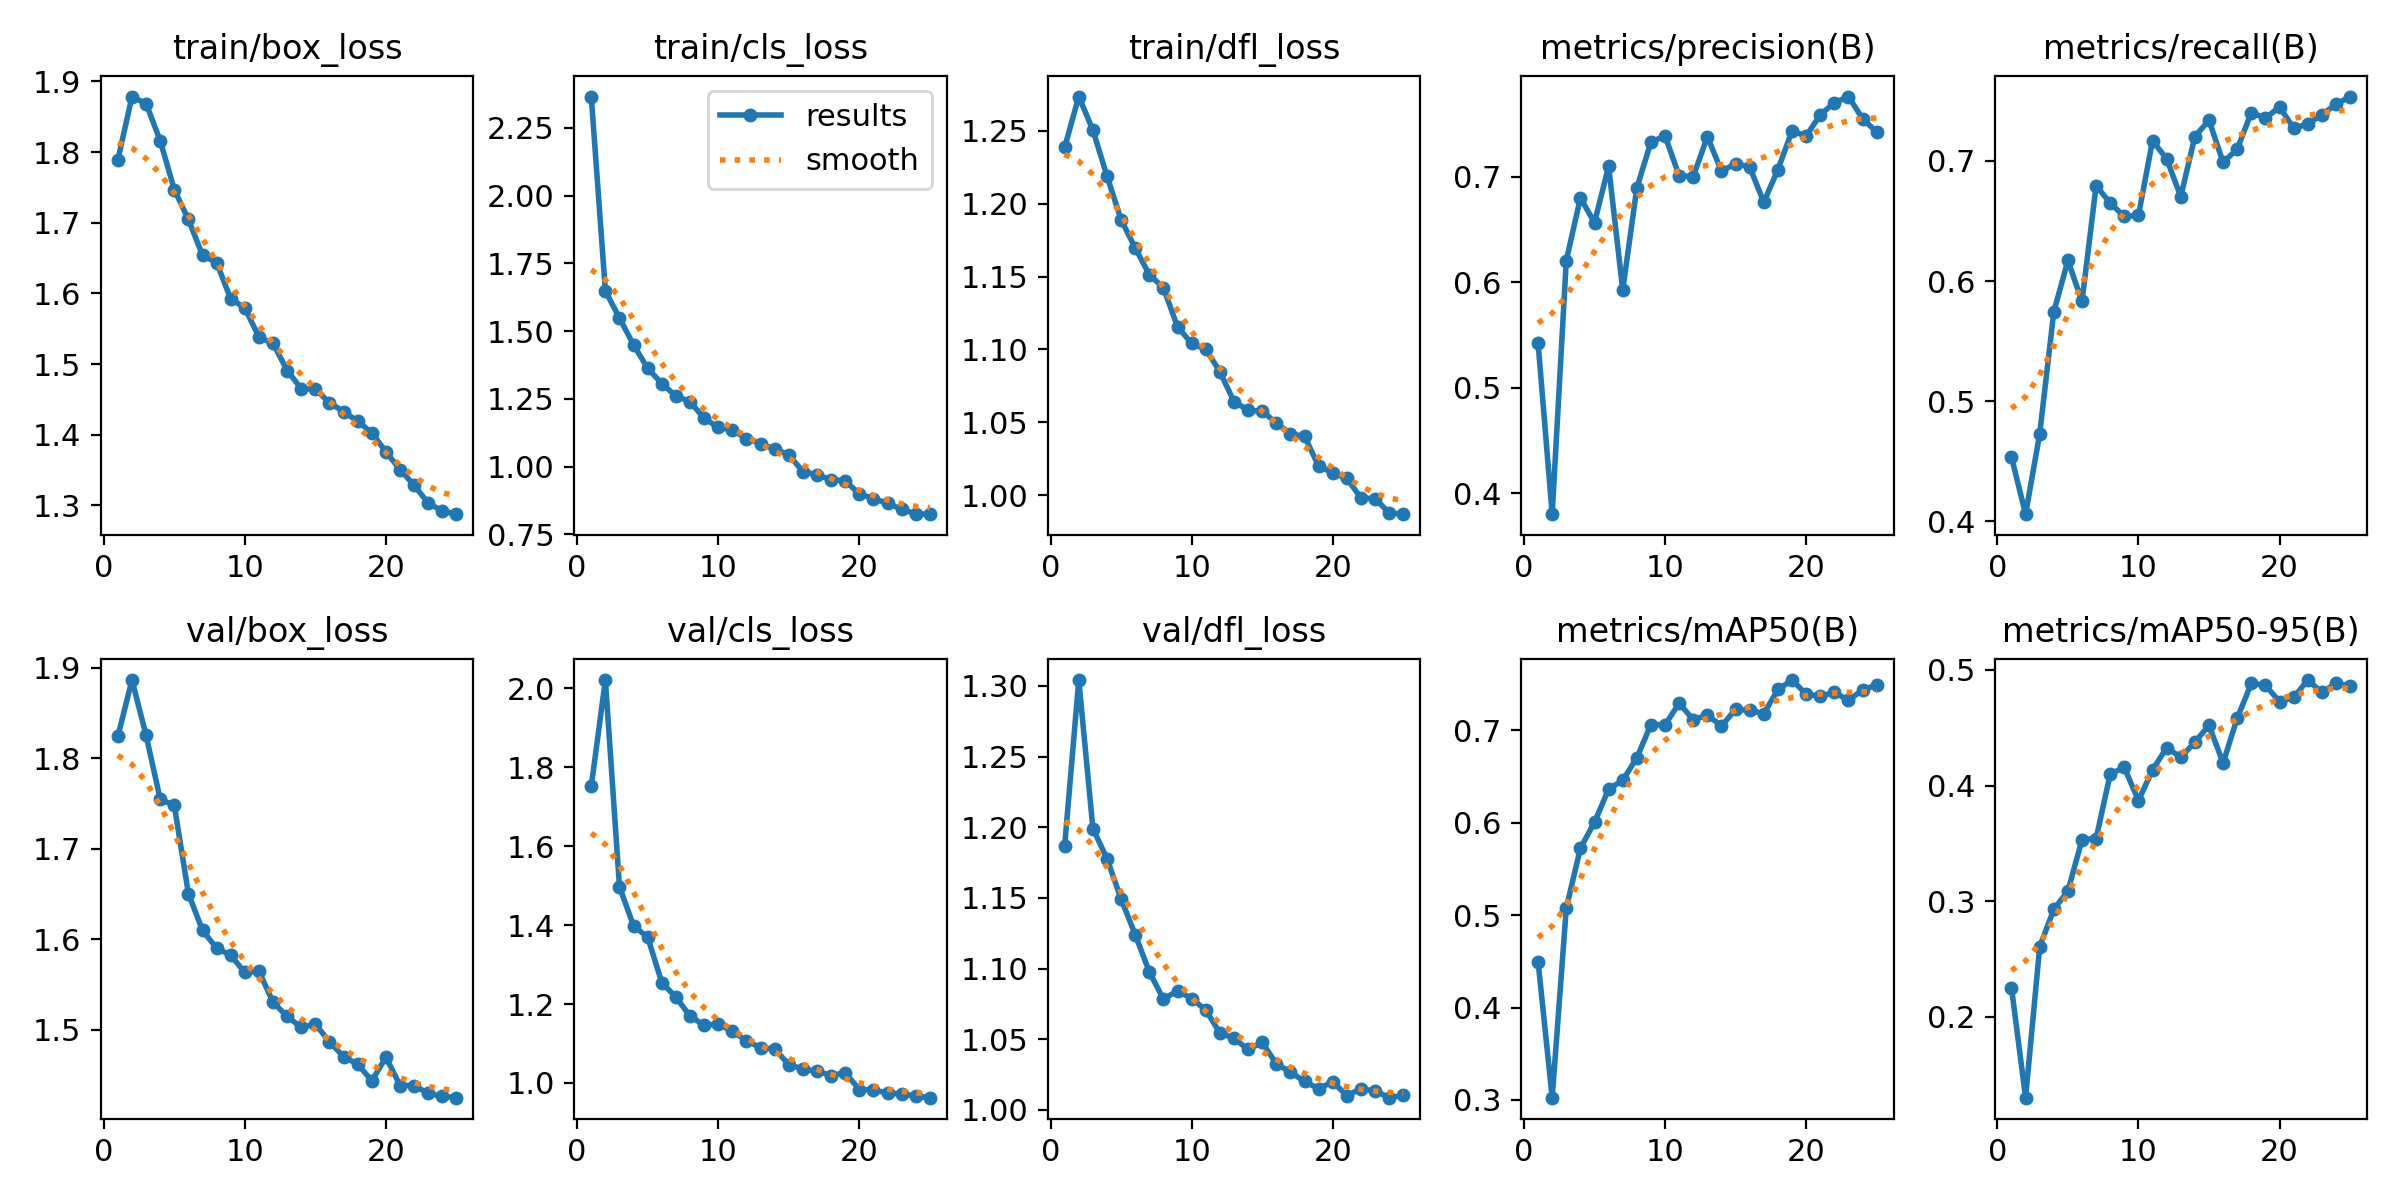

In [ ]:
from pathlib import Path
from IPython.display import Image, display

result_png = Path("/content/runs/detect/runs/yolov8s_balanced_fast/results.png")

if result_png.exists():
    display(Image(filename=str(result_png)))
else:
    print("results.png not found yet. It may appear after training progresses.")
    print("Checked path:", result_png)

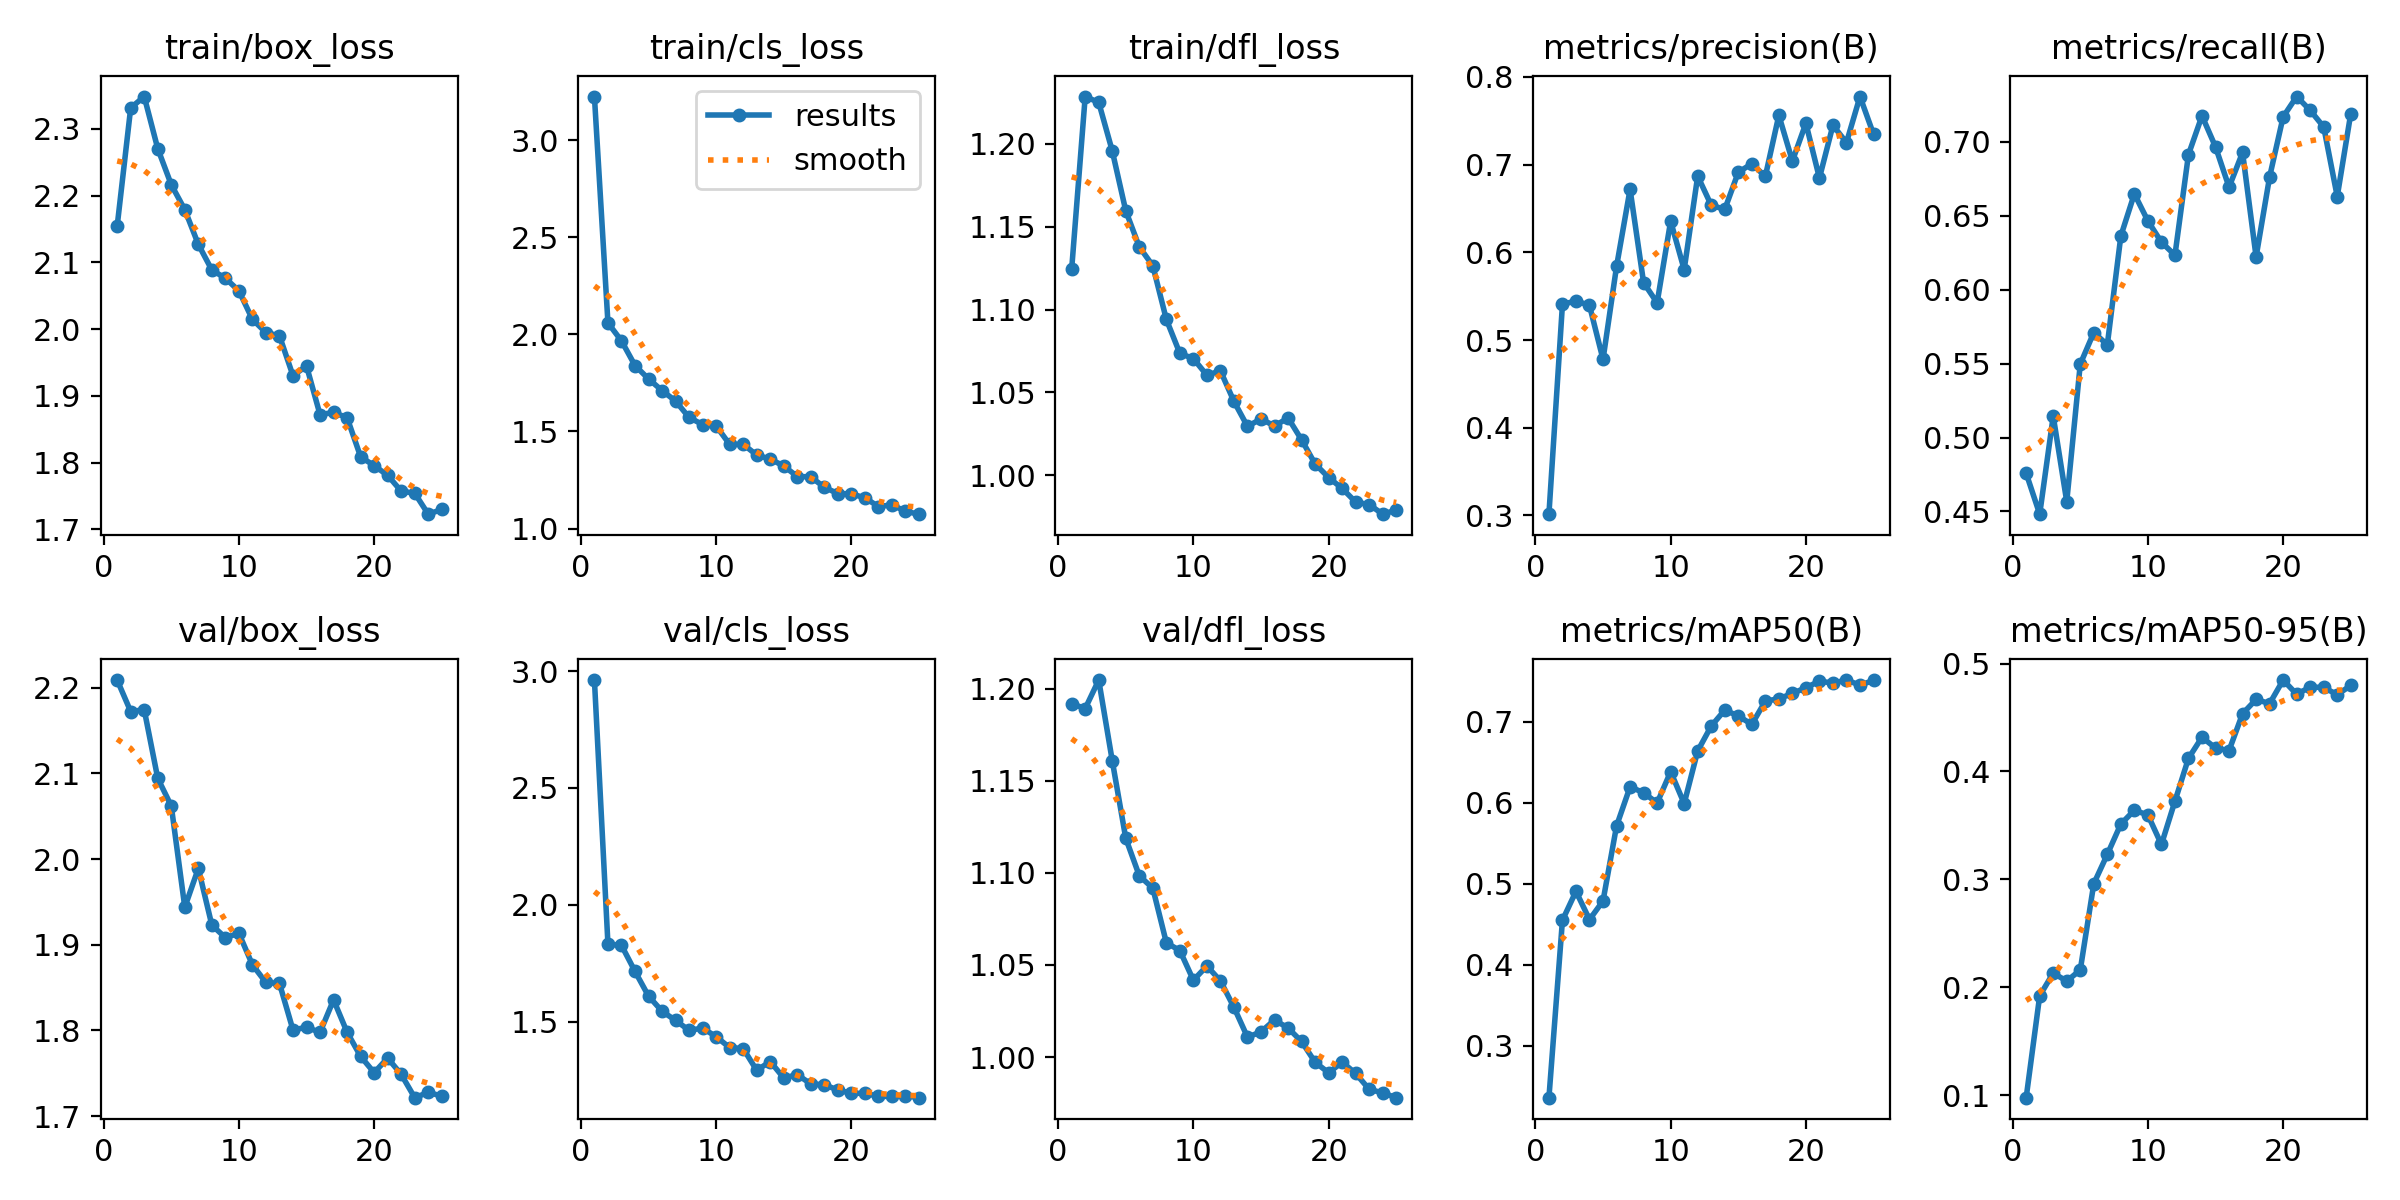

In [ ]:
from pathlib import Path
from IPython.display import Image, display

result_png = Path("/content/runs/detect/runs/yolov10s_balanced_fast/results.png")

if result_png.exists():
    display(Image(filename=str(result_png)))
else:
    print("results.png not found yet. It may appear after training progresses.")
    print("Checked path:", result_png)

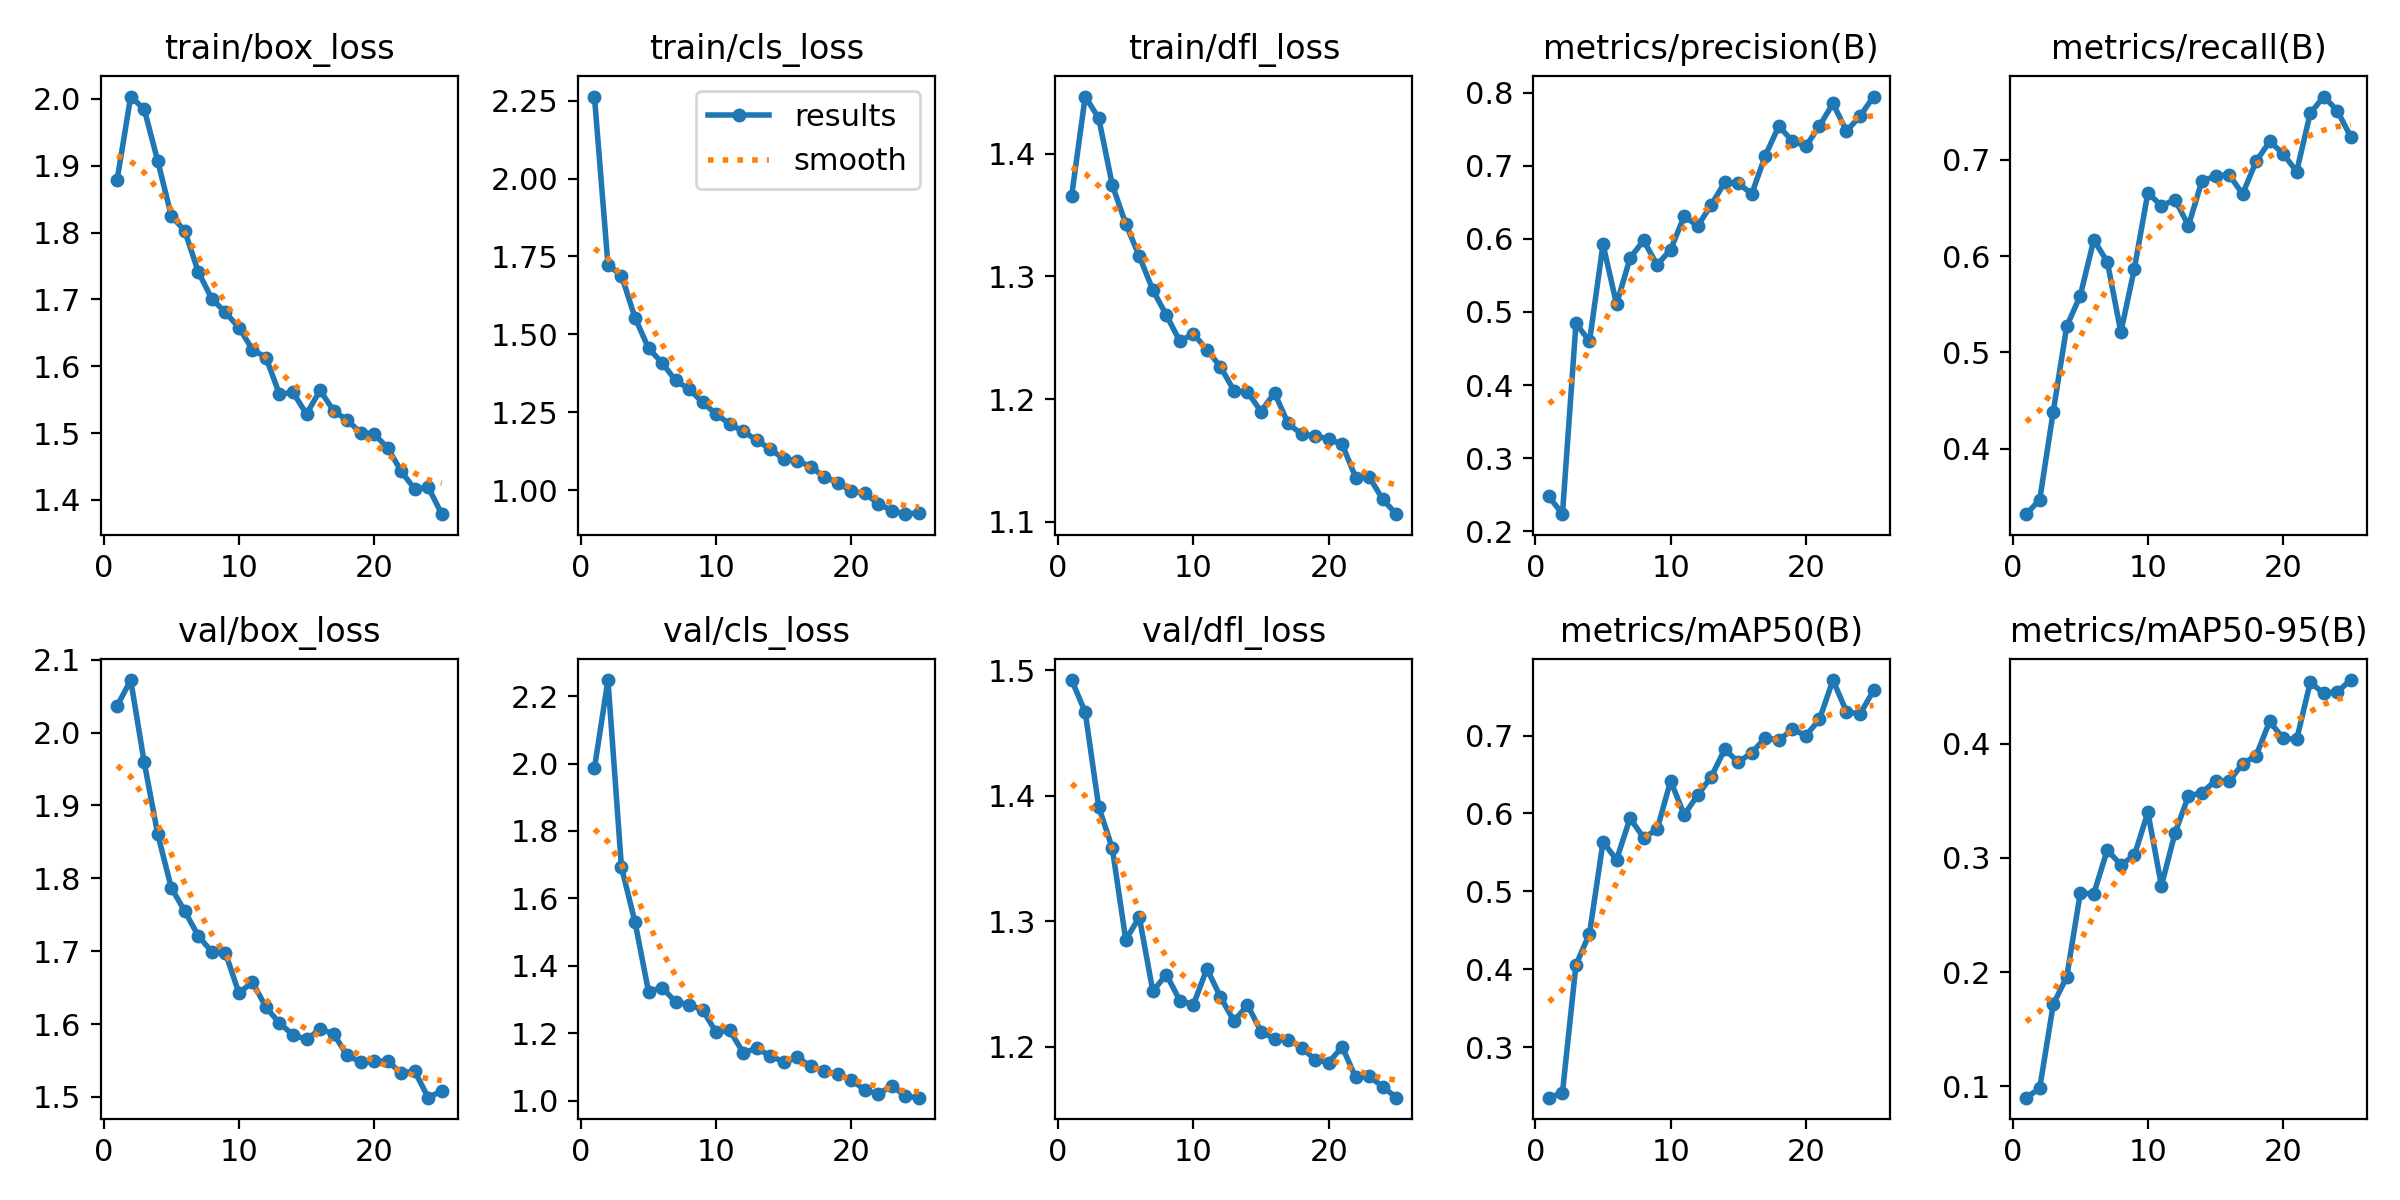

In [ ]:
from pathlib import Path
from IPython.display import Image, display

result_png = Path("/content/runs/detect/runs/yolo12s_balanced_fast/results.png")

if result_png.exists():
    display(Image(filename=str(result_png)))
else:
    print("results.png not found yet. It may appear after training progresses.")
    print("Checked path:", result_png)

In [ ]:
from pathlib import Path
from IPython.display import Image, display

result_png = Path("/content/runs/detect/runs/rtdetr-l_balanced_fast/results.png")

if result_png.exists():
    display(Image(filename=str(result_png)))
else:
    print("results.png not found yet. It may appear after training progresses.")
    print("Checked path:", result_png)

In [ ]:
from google.colab import files
import shutil
from pathlib import Path

folder_path = Path("/content/runs/detect/runs/rtdetr-l_balanced_fast")
zip_path = "/content/rtdetr-l_balanced_fast"

if folder_path.exists():
    shutil.make_archive(zip_path, "zip", folder_path)
    files.download(zip_path + ".zip")
else:
    print("폴더가 없습니다:", folder_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>